In [ ]:
require(data.table)
require(tidyverse)
require(phyloseq)
require(ggplot2)
require(RColorBrewer)
require(metacoder)
require(vegan)
require(DESeq2)
options(repr.plot.width=20, repr.plot.height=15)

### 479 samples instead of 480 because 042024_T1_429_PAST was an AS

In [2]:
ps<-readRDS(file = "/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/BEL_16S_outputs/ps_16S.rds")
#removing any taxa that don't show up in any samples to speed up the process
ps

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 268938 taxa and 479 samples ]
sample_data() Sample Data:       [ 479 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 268938 taxa by 6 taxonomic ranks ]

## investigate total read counts
- make sure negatives have low numbers of reads
1. reads histogram
2. create total_reads table

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


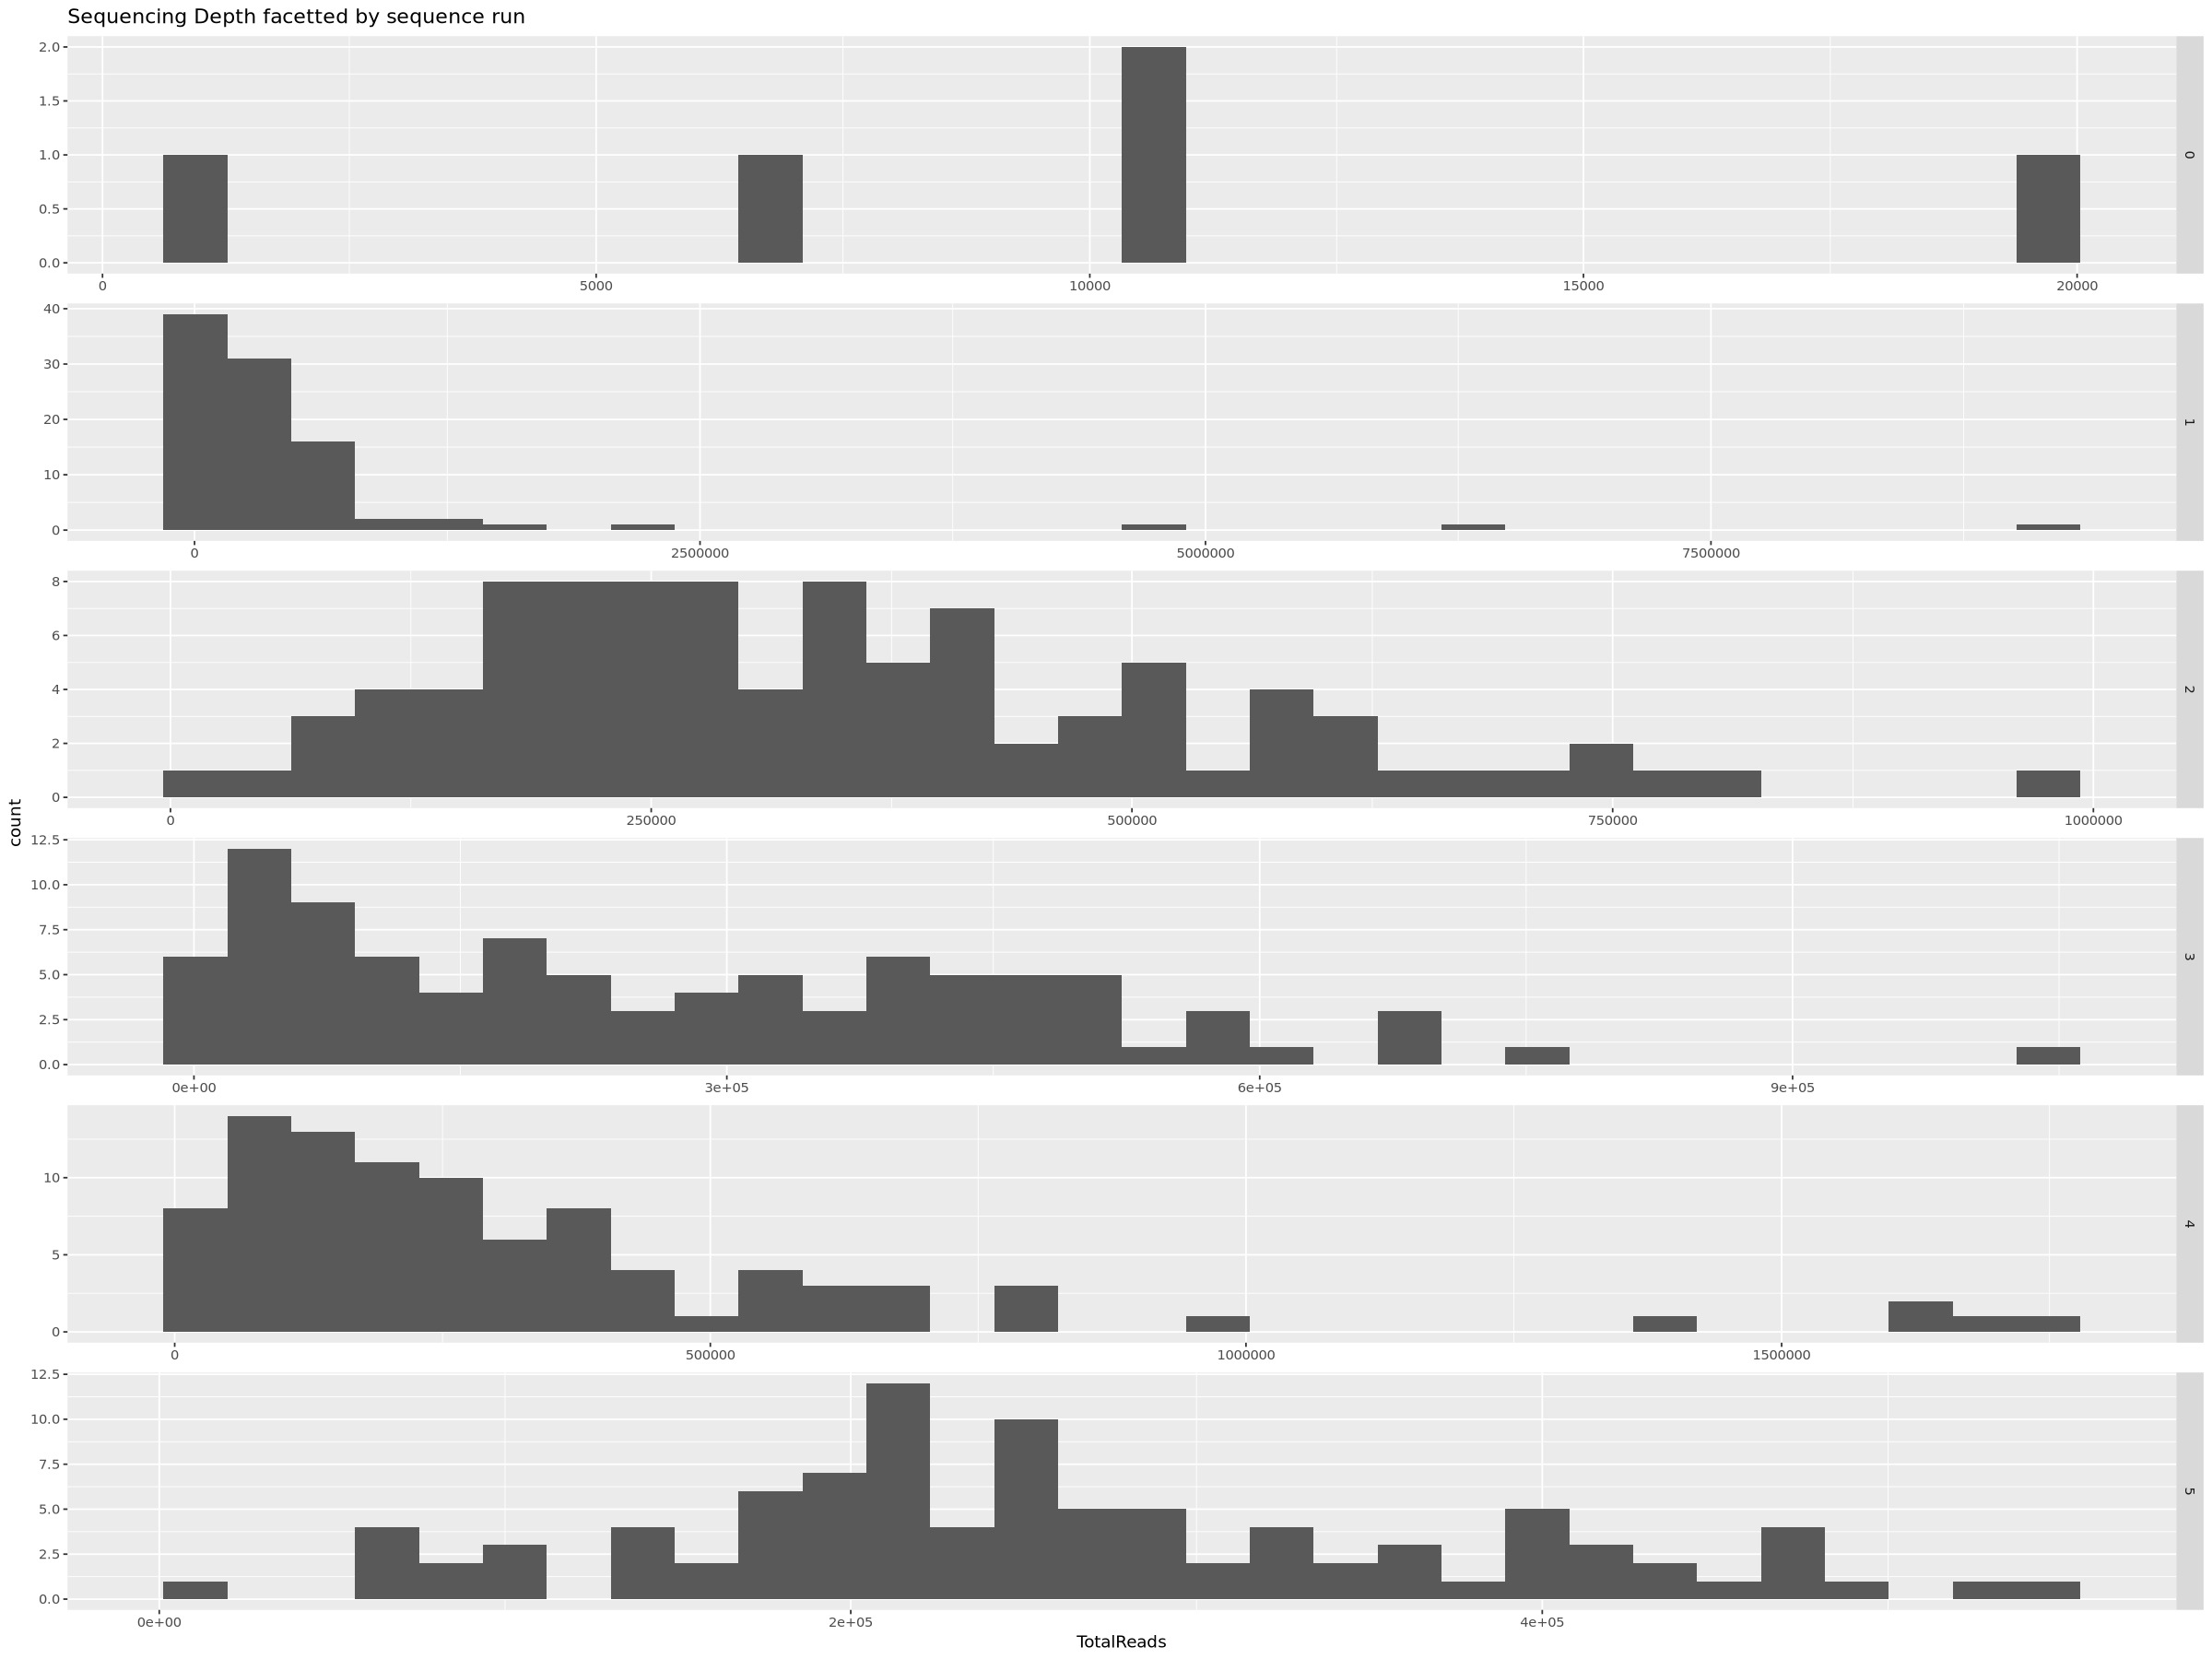

In [3]:
# Check read count
readcount = data.table(as(sample_data(ps), "data.frame"),
                 TotalReads = sample_sums(ps), 
                 keep.rownames = TRUE)
setnames(readcount, "rn", "SampleID")
ggplot(readcount, aes(TotalReads)) + geom_histogram() + ggtitle("Sequencing Depth facetted by sequence run") + facet_wrap(Seq_run ~., strip.position = "right",  ncol = 1, scales="free")  # Set desired font size

### figure notes
- negative controls are listed as seq run 0. they all have less than 2000 reads

In [4]:
total_reads <- print(readcount[order(readcount$TotalReads), c("SampleID", "TotalReads")])

# median reads
median(readcount$TotalReads)

# mean reads
mean(readcount$TotalReads)

# minimum read number
readcount[, min(TotalReads)]

                        SampleID TotalReads
                          <char>      <num>
  1:  012024_BEL_CBC_T1_561_OANN        765
  2:                    Negative        940
  3:  042024_BEL_CBC_T3_960_OFAV       3853
  4:  122022_BEL_CBC_T3_142_MCAV       4868
  5:                  Negative.4       6771
 ---                                       
475:  012024_BEL_CBC_T3_625_SSID    1749091
476: 042024_BEL_CBC_T2_1018_PAST    2096344
477: 082024_BEL_CBC_T3_1562_OFAV    4651047
478: 062024_BEL_CBC_T2_1375_SSID    6257366
479:  092023_BEL_CBC_T2_184_MCAV    9169329


[1] 257489

[1] 348608.4

[1] 765

## clean phyloseq object
- remove chloroplast and mitochondrial taxa
- remove singletons

In [5]:
#isolate just bacteria
ps_bac=subset_taxa(ps, Kingdom=="Bacteria")
ps_bac

#remove chloroplast order
ps_nochlo=subset_taxa(ps_bac, Order!="Chloroplast")
ps_nochlo

#remove mitochondria family
ps_nomit=subset_taxa(ps_nochlo, Family!="Mitochondria")
ps_nomit

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 104196 taxa and 479 samples ]
sample_data() Sample Data:       [ 479 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 104196 taxa by 6 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 78949 taxa and 479 samples ]
sample_data() Sample Data:       [ 479 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 78949 taxa by 6 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46684 taxa and 479 samples ]
sample_data() Sample Data:       [ 479 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 46684 taxa by 6 taxonomic ranks ]

In [6]:
#removing any taxa that don't show up in any samples to speed up the process

#maybe I should up to 1 to remove singletons
ps_prune <- prune_taxa(taxa_sums(ps_nomit) > 0, ps_nomit)
ps_prune

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46551 taxa and 479 samples ]
sample_data() Sample Data:       [ 479 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 46551 taxa by 6 taxonomic ranks ]

# what taxa show up?

Warning message:
“Some columns are a multi-column type (such as a matrix column): [1, 2, 3, 4, 5, 6]. setDT will retain these columns as-is but subsequent operations like grouping and joining may fail. Please consider as.data.table() instead which will create a new column for each embedded column.”
Warning message:
“Some columns are a multi-column type (such as a matrix column): [1, 2, 3, 4, 5, 6]. setDT will retain these columns as-is but subsequent operations like grouping and joining may fail. Please consider as.data.table() instead which will create a new column for each embedded column.”
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


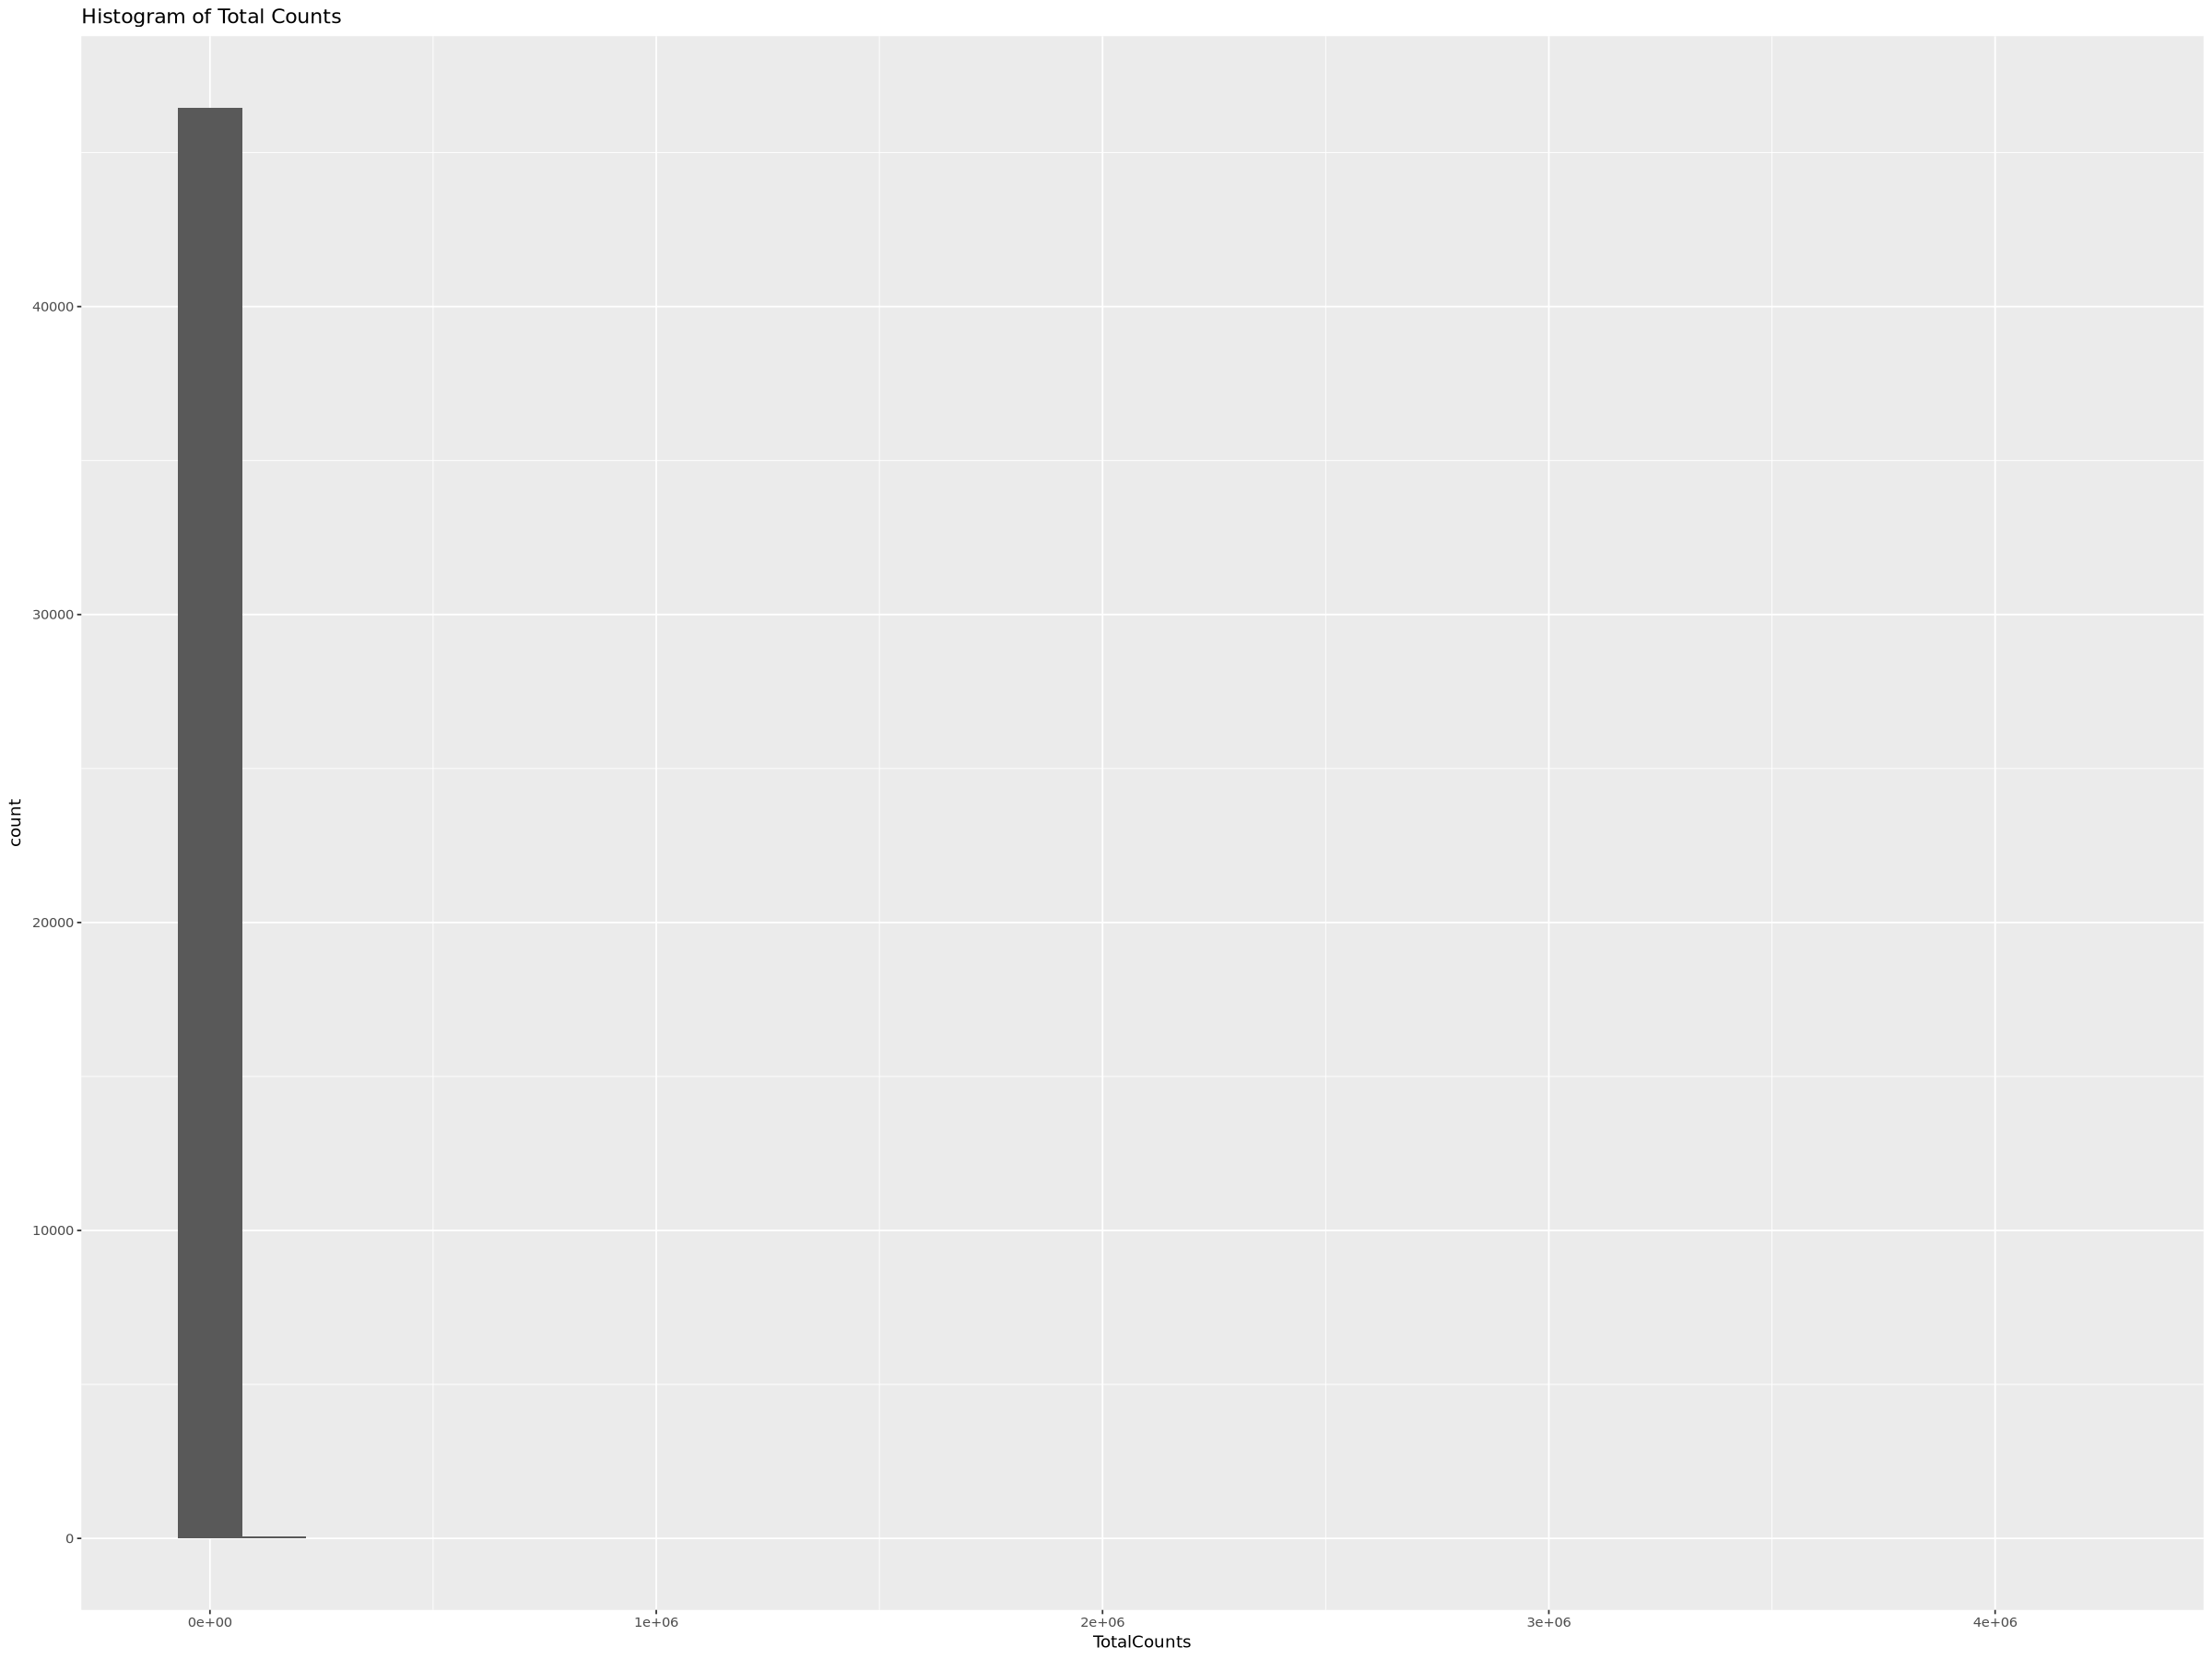

In [7]:
tdt = data.table(tax_table(ps_prune),
                 TotalCounts = taxa_sums(ps_prune),
                 OTU = taxa_names(ps_prune))
ggplot(tdt, aes(TotalCounts)) + 
  geom_histogram() + 
  ggtitle("Histogram of Total Counts")

### figure notes
- most otus show up less than 1E06 times

## are there any super rare OTUs?

In [8]:
# How many singletons?
tdt[(TotalCounts <= 0), .N]

# already filtered for otus that don't show up in any samples
#313 in ps
tdt[(TotalCounts <= 1), .N]

# 5 OTU singletons in ps_prine
#there are 325 OTU in ps

# How many doubletons?
tdt[(TotalCounts <= 2), .N]
# 787 doubleton otus in ps_prune
#there are 2964 otu that only show up twice

[1] 0

[1] 5

[1] 787

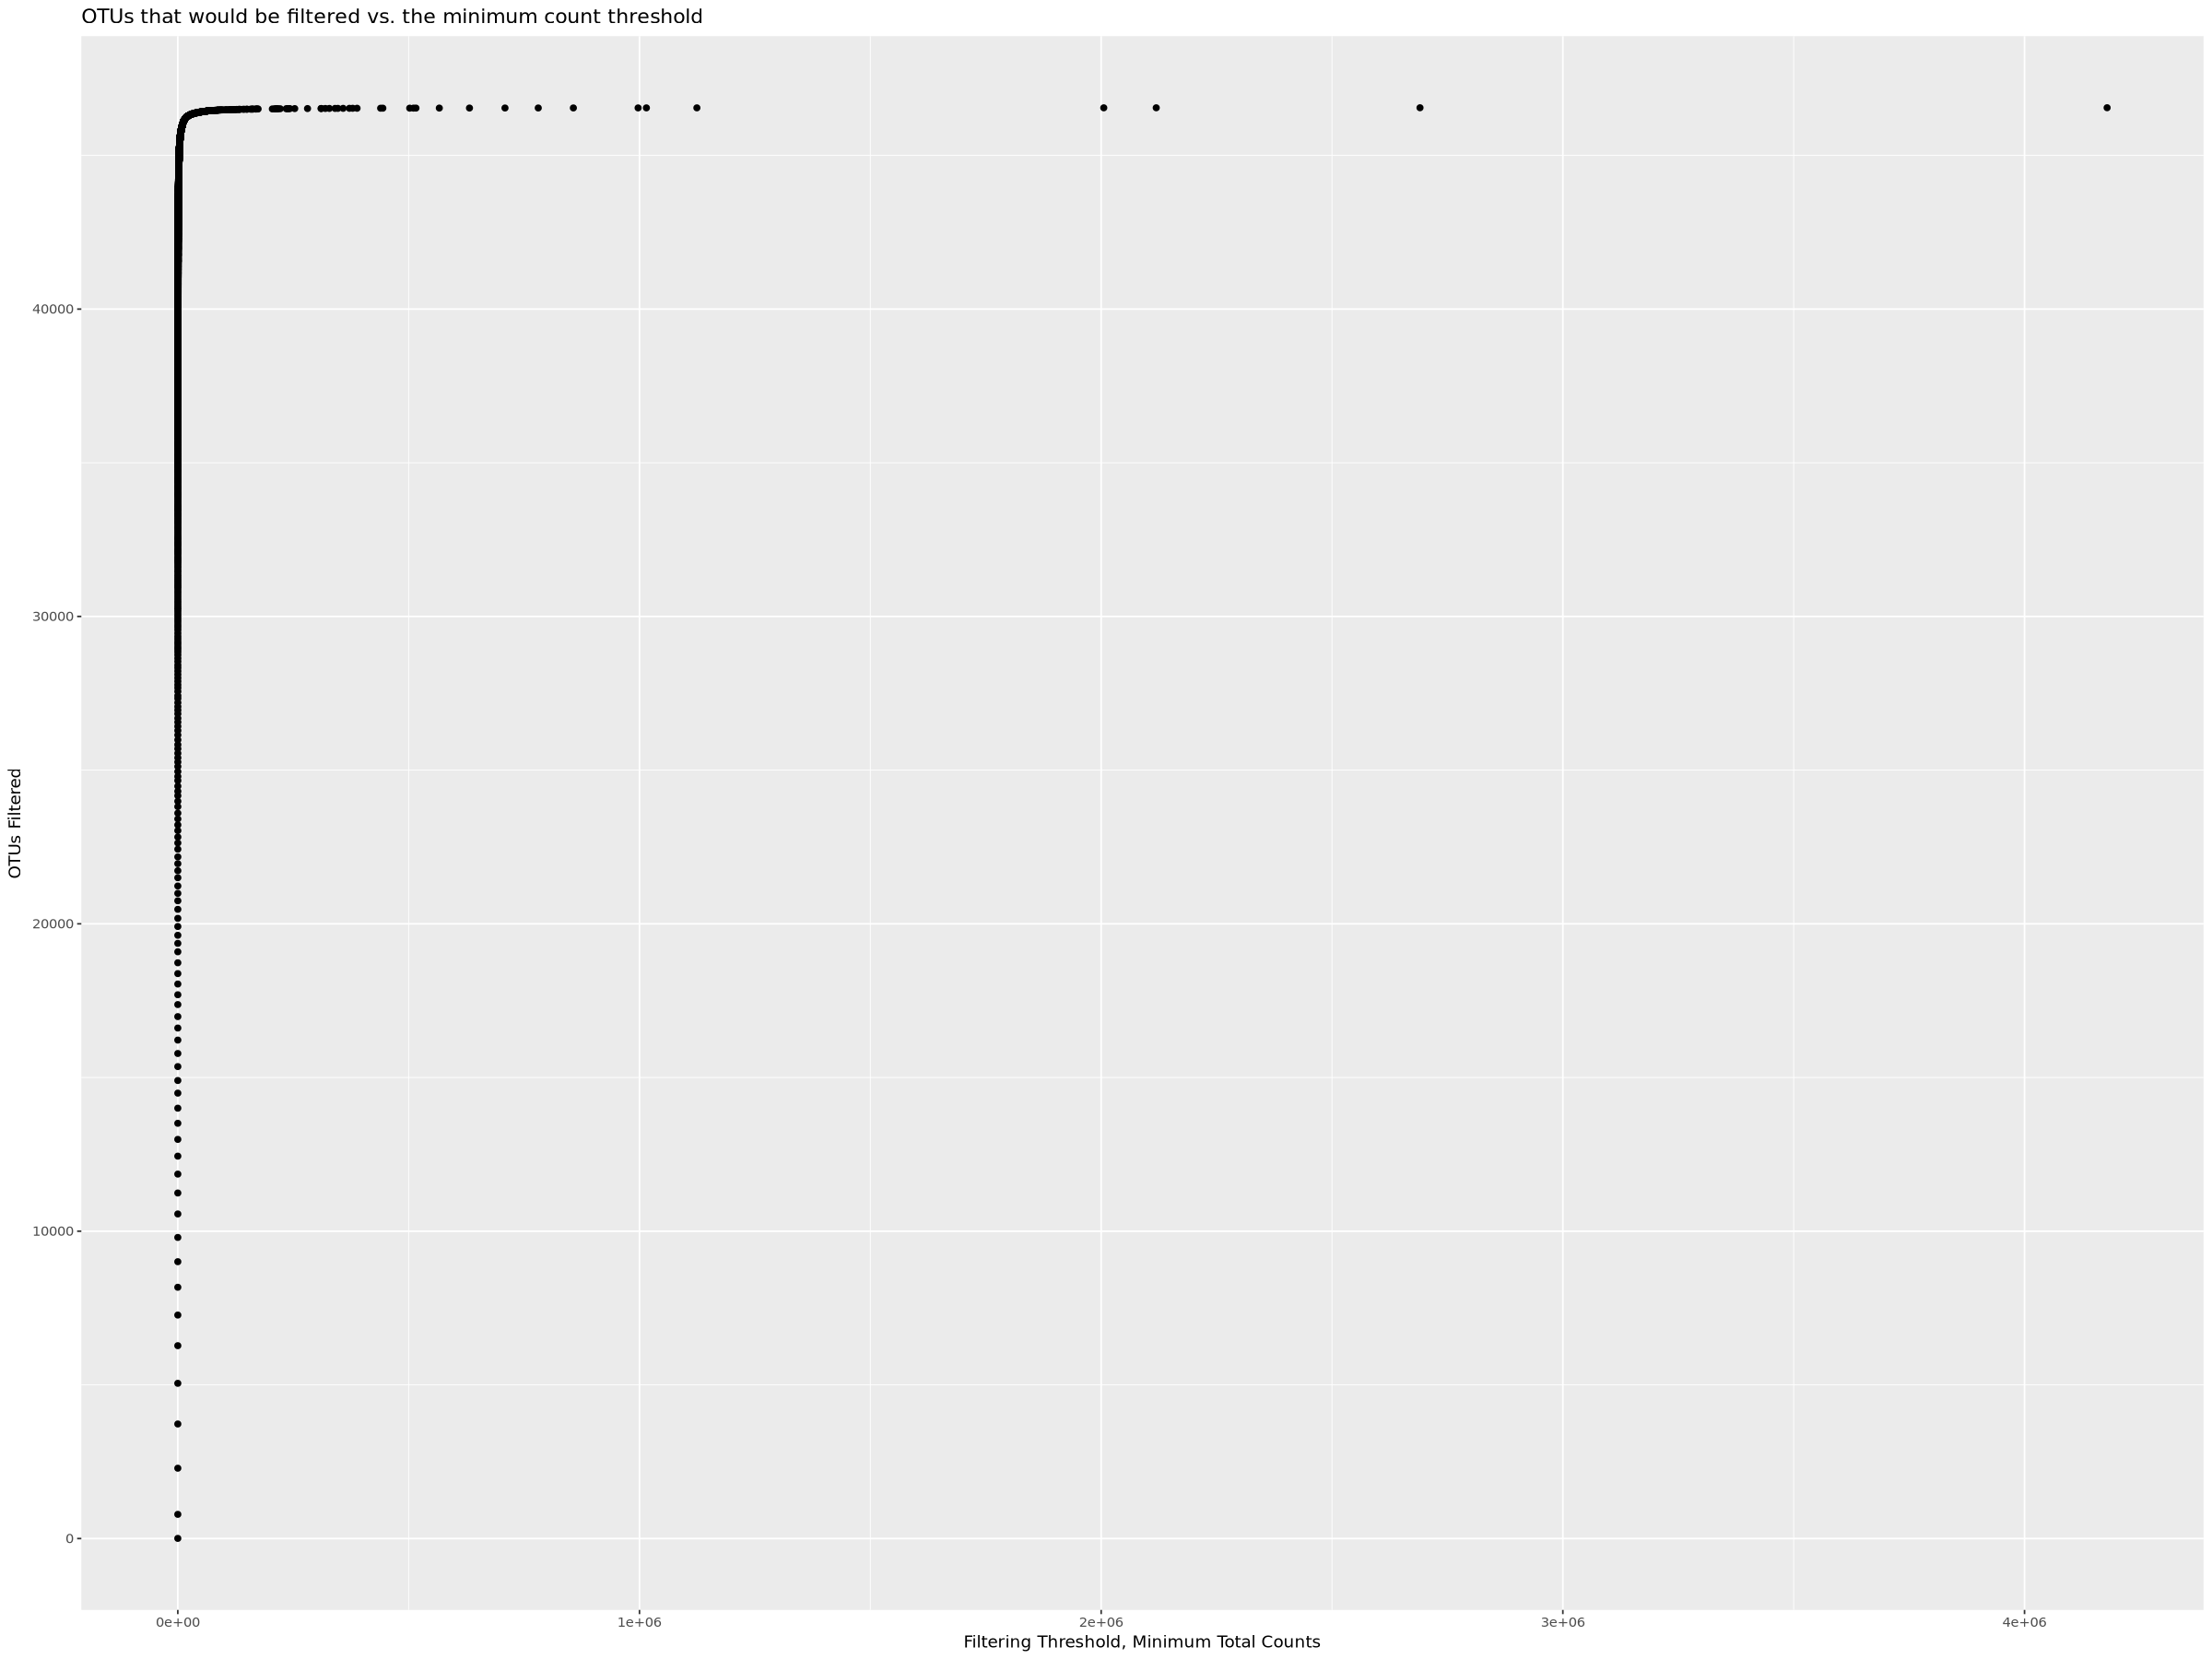

In [9]:
# taxa cumulative sum
taxcumsum = tdt[, .N, by = TotalCounts]
setkey(taxcumsum, TotalCounts)
taxcumsum[, CumSum := cumsum(N)]
# Define the plot
pCumSum = ggplot(taxcumsum, aes(TotalCounts, CumSum)) + 
  geom_point() +
  xlab("Filtering Threshold, Minimum Total Counts") +
  ylab("OTUs Filtered") +
  ggtitle("OTUs that would be filtered vs. the minimum count threshold")
pCumSum

Warning message:
“Removed 553 rows containing missing values or values outside the scale range
(`geom_point()`).”


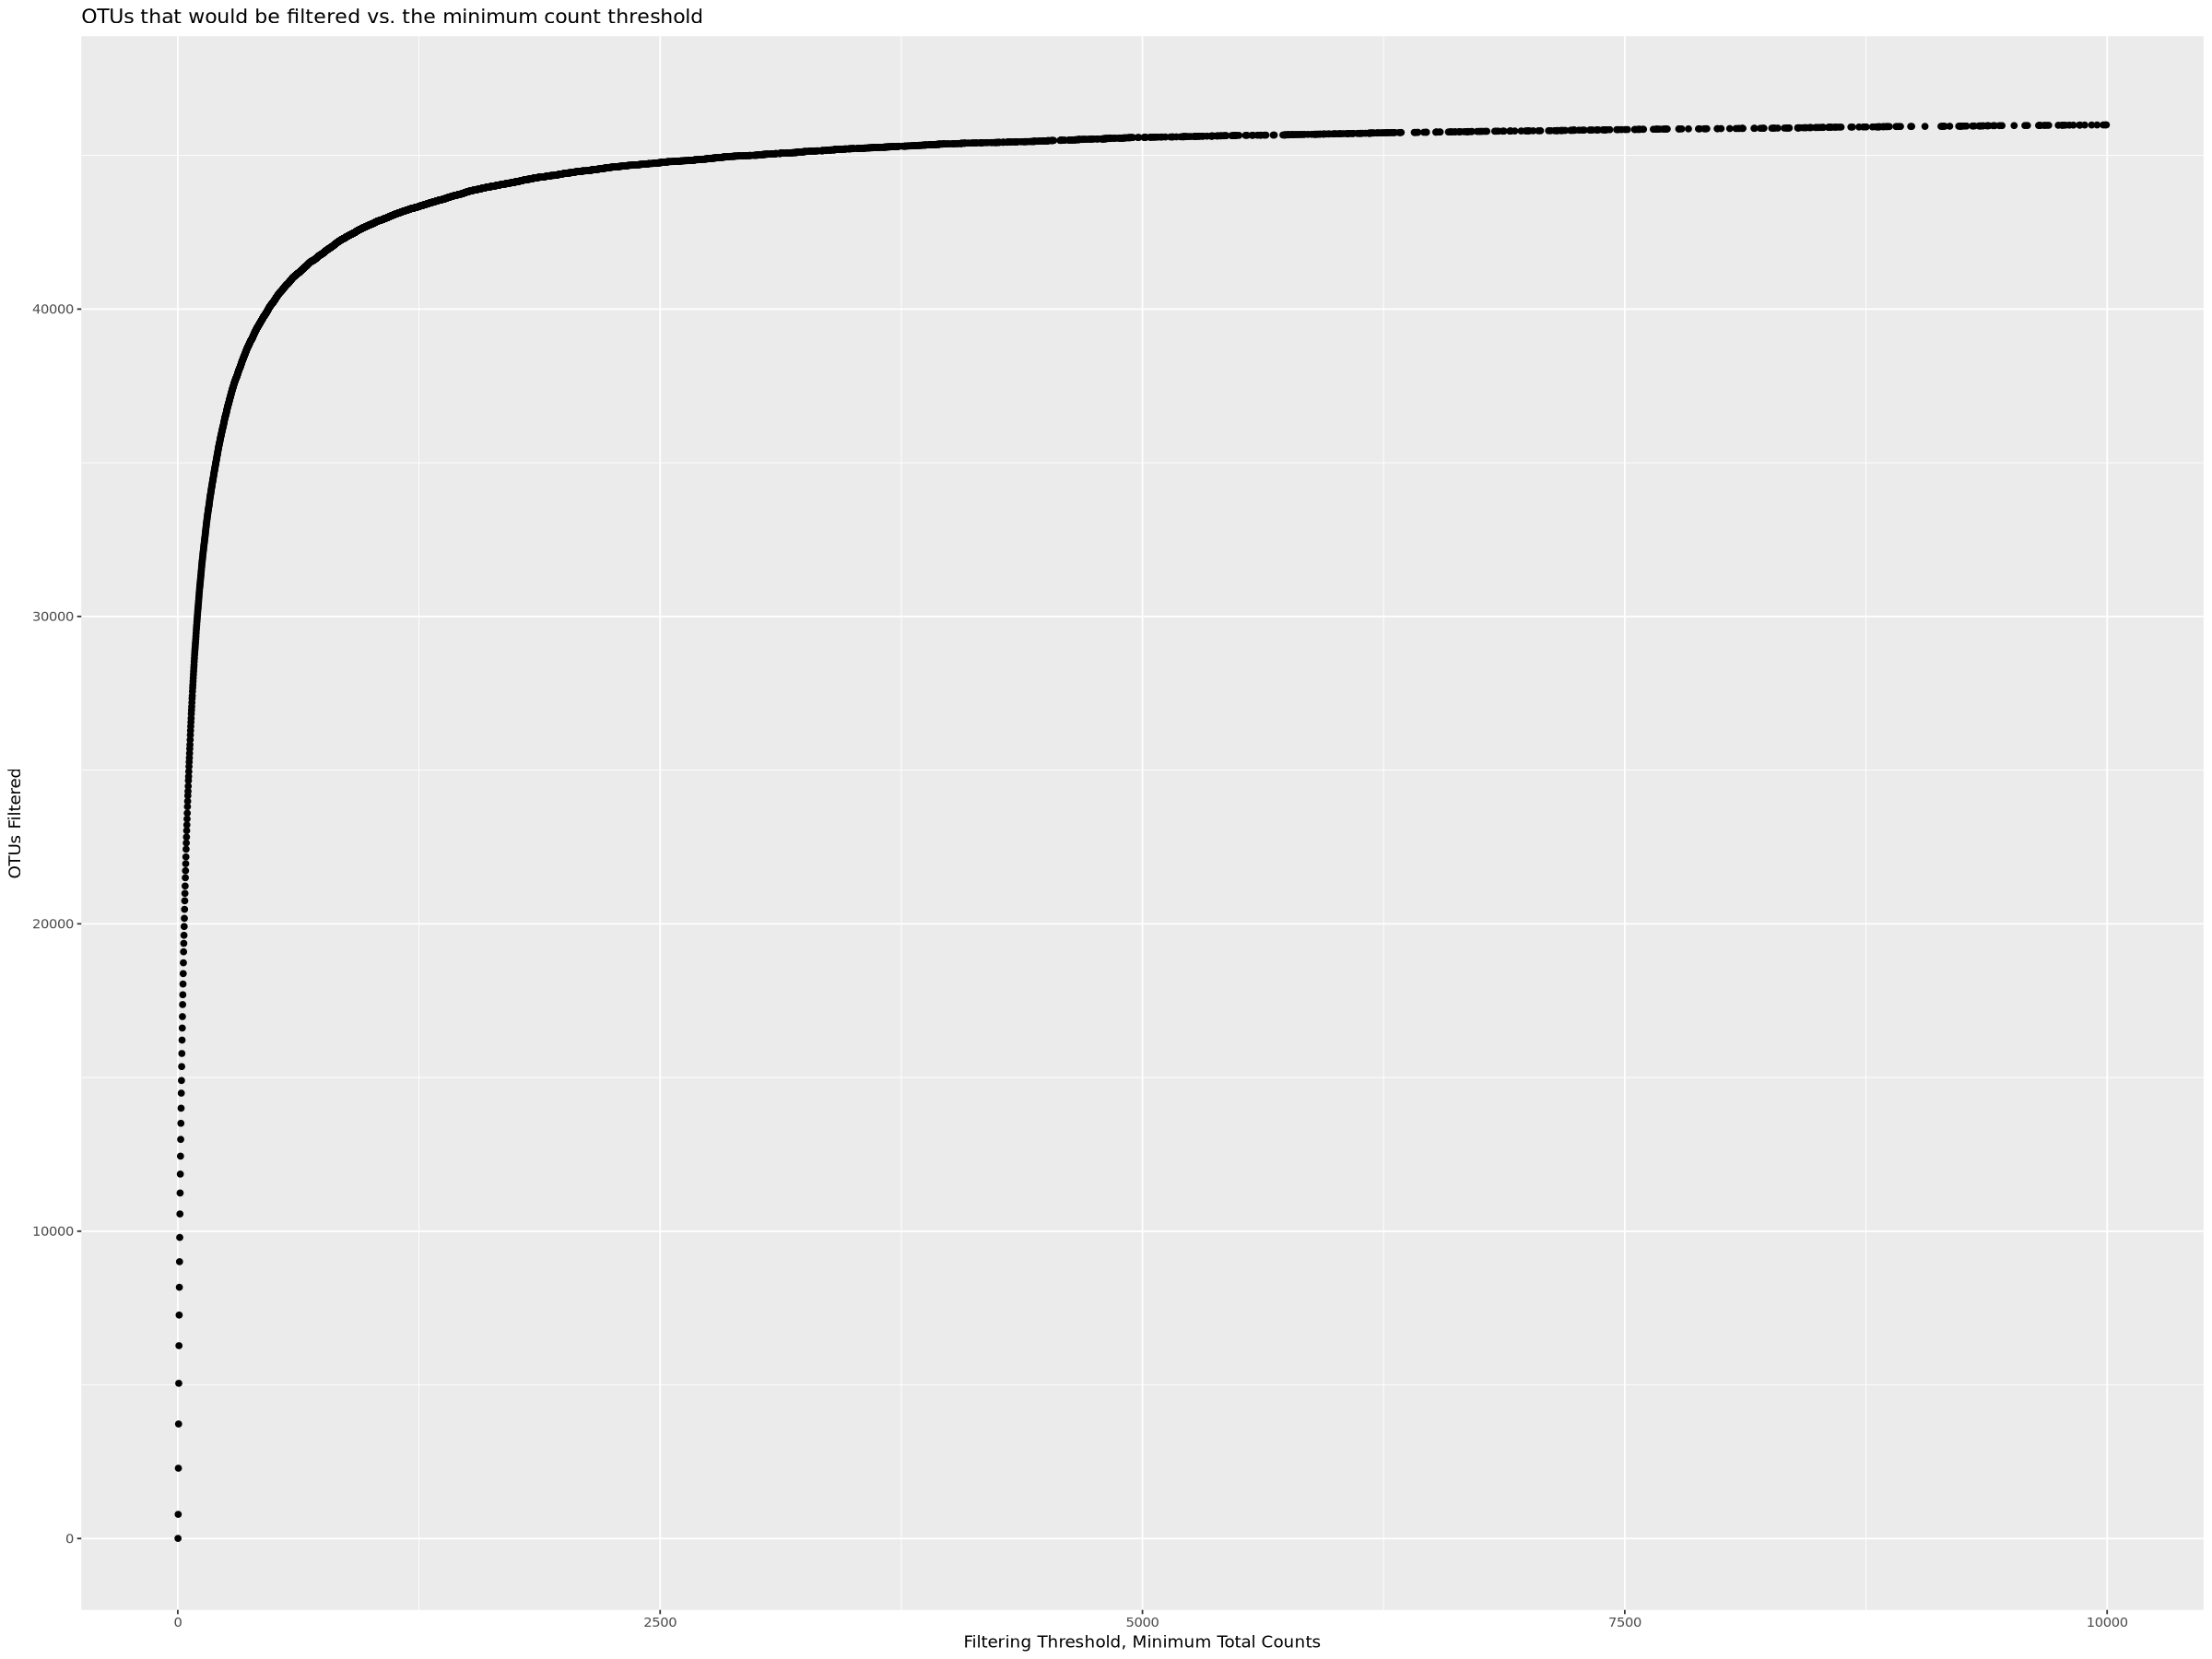

In [10]:
# Zoom-in to 0-10000 otu counts
pCumSum + xlim(0, 10000)

### figure notes 

**I dont really know what the point of plotting this is https://evomics.org/wp-content/uploads/2016/01/phyloseq-Lab-01-Answers.html**

- cumulative sum of OTUs that would be filtered at every possible value of such a threshold, from zero to the most-observed OTU.

- this plot shows us that if I filter out OTu's that appear less than 1000 times then I will be losing 40,000 OTUs

- goal is to justify and document decision for filtering. The goal of filtering is to remove noise from the data, in this case noisy variables that are unlikely to provide any useful information. Our criteria for this filtering should not include variables from which we want to infer biological insights later on. Why is that?




## generate a rarefaction curve for ps
- As the curve flattens, it suggests that the sequencing data volume is optimised (additional data would yield only a minimal increase in new OTUs)
- rarefaction curve could be used to determined whether the sequencing depth cover microbial diversity of the sample

In [ ]:
otu.rare = otu_table(ps)
otu.rare = as.data.frame(t(otu.rare))
sample_names = rownames(otu.rare)

# we will use vegan rarecurve 
otu.rarecurve = rarecurve(otu.rare)


empty rows removed



### removing samples with less than 10K reads
- removes 5 negative controls and 7 samples
- **what are the 7 samples?**

In [ ]:
# remove low read counts
ps_high <- prune_samples(sample_sums(ps_prune) >= 10000, ps_prune)

In [ ]:
# which samples were removed?
setdiff(sample_names(ps_prune), sample_names(ps_high))